# A GPS-only agent that finds where a haul fleet loses time

*Baruun Naran, load zone 25559. Rebuilt 2026-08-07.*

The question this notebook is trying to answer is not "how fast is this mine" but **can a piece
of software, given nothing but GPS pings, work out how the mine actually operates and then say
what to fix?**

The chain is: **raw GPS → cycles → discover the loop's topology → account for every minute →
rank the levers**. No step needs a human to say what a place is for, which matters, because we
have no site contact and a hard-coded list of one mine's Mongolian place names would not
transfer anywhere else.

Two things worth knowing before the numbers:

**What we got wrong before.** The earlier version ranked *"fix the empty-return road"* as the #1
lever at +16 loads/day. It was an artefact. `return_s` is one timestamp minus another, so
anything the truck did in between — a shift handover, a weighbridge, a tarping point, queueing
outside the pit gate — was invisible and got charged to the road. Only **56%** of "road" time is
a truck driving. Once separated, the empty-return road drops to **#8 (+1.6/day)**, in every one
of the five months.

**What we are not claiming.** The headline is reported as a range, not a point, because the data
cannot locate a point. Every hand-set number is named below, and the ones that could change an
answer have been swept.

In [ ]:
import sys, os, warnings
sys.path.insert(0, '.')
sys.path.insert(0, '../fleet_agent')   # agent_v2 moved there
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import agent_v2 as A

ZONE, MONTH = 25559, '2025-11'
MONTHS = ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
TEAL, ORANGE, BLUE, GREY, RED = '#1b9e8a', '#e6820a', '#3b6ea5', '#9aa0a6', '#c0392b'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('ok')

ok


## 1 — Building the loop from raw pings

`build_cycles(month)` takes a month of GPS it has never seen, joins each ping to the mine's
material-zone polygons, collapses consecutive pings in one zone into a visit, and reads off
`load → unload → load` cycles. Cycles longer than 6 h are dropped as offline gaps or shift
breaks.

Everything downstream runs on this table, so having it *inside* the agent — rather than
depending on a pre-baked CSV — is what lets us hand the thing a new month.

In [2]:
cyc = A.load_cycles(ZONE, MONTH)          # builds from raw GPS if the month is unknown
print(f"{len(cyc)} cycles | {cyc.tracker_id.nunique()} trucks | {cyc.date.nunique()} days")
print(f"  over 6 h: {int(cyc.over_max_hours.sum())}   ping gap > 15 min: {int((cyc.max_gap_s > 900).sum())}")
print(f"  load-zone stay: median {cyc.dwell_s.median()/60:.1f} min "
      f"(measured from this visit's own arrival and departure)")
cyc[['tracker_id','depart_load','arrive_unload','depart_unload','arrive_load',
     'haul_s','dump_s','return_s','cycle_s','dwell_own_s','max_gap_s']].head(3)


2657 cycles | 22 trucks | 30 days
  over 6 h: 314   ping gap > 15 min: 171
  load-zone stay: median 21.1 min (measured from this visit's own arrival and departure)


,tracker_id,depart_load,arrive_unload,depart_unload,arrive_load,haul_s,dump_s,return_s,cycle_s,dwell_own_s,max_gap_s
0,20505,2025-11-05 20:45:04,2025-11-05 21:47:44,2025-11-05 21:54:01,2025-11-05 23:05:12,3760.0,377.0,4271.0,8408.0,1483.0,20.0
1,20505,2025-11-05 23:29:55,2025-11-06 00:47:27,2025-11-06 00:48:44,2025-11-06 01:51:02,4652.0,77.0,3738.0,8467.0,1143.0,20.0
2,20505,2025-11-06 02:10:05,2025-11-06 03:16:47,2025-11-06 03:18:45,2025-11-06 04:06:51,4002.0,118.0,2886.0,7006.0,580.0,20.0


old median 27 min, 13% over 150 min
new median 21 min, 0.1% over 150 min


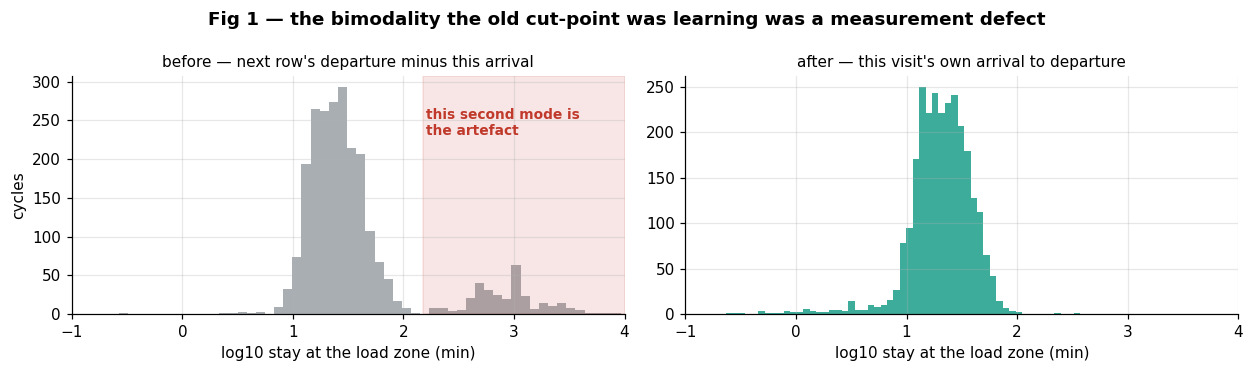

In [3]:
# The load-zone stay, measured two ways. The learned GMM cut-point is gone from the
# method: it existed to separate genuine stays from an artefact, and the artefact is fixed.
old = pd.read_csv(A.CYCLES_CSV, parse_dates=['depart_load', 'arrive_load'])
old = old[(old.region == 'bn') & (old.load_zone == ZONE) & (old.month == MONTH)]
old = old.sort_values(['tracker_id', 'depart_load'])
od = ((old.groupby('tracker_id')['depart_load'].shift(-1) - old.arrive_load)
      .dt.total_seconds() / 60).dropna()
od = od[od > 0]
nd = cyc['dwell_s'].dropna() / 60
svc = dx_svc = A.tag_causes(cyc, None)[3] / 60 if False else None

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].hist(np.log10(od), bins=55, color=GREY, alpha=.85)
axes[0].axvspan(np.log10(150), 4, color=RED, alpha=.12)
axes[0].set_title("before — next row's departure minus this arrival", fontsize=10)
axes[0].text(2.2, axes[0].get_ylim()[1]*.75, 'this second mode is\nthe artefact', color=RED,
             fontsize=9, fontweight='bold')
axes[1].hist(np.log10(nd), bins=55, color=TEAL, alpha=.85)
axes[1].set_title("after — this visit's own arrival to departure", fontsize=10)
for a_ in axes:
    a_.set_xlabel('log10 stay at the load zone (min)'); a_.set_xlim(-1, 4)
axes[0].set_ylabel('cycles')
fig.suptitle('Fig 1 — the bimodality the old cut-point was learning was a measurement defect',
             fontweight='bold')
fig.tight_layout(); fig.savefig('nb_v4_fig1_dwell.png', dpi=130)
print(f'old median {od.median():.0f} min, {(od>150).mean()*100:.0f}% over 150 min')
print(f'new median {nd.median():.0f} min, {(nd>150).mean()*100:.1f}% over 150 min')


## 2 — Discovering the topology: what is a station, what is just a place we drive past

This is the step that replaces our judgement with a measurement. For every zone the mine has
drawn, we ask two questions of the GPS:

1. **Does every trip pass here?** `coverage = visits / cycles`. A place passed on both legs of
   every trip scores ~200%.
2. **Do trucks actually stop here?** the share of visits containing a ping at ≤2 km/h.

Coverage alone is not enough — junctions and mileposts also score ~200%, because every truck
*drives through* them. The second question separates them, and it separates them cleanly:

| | coverage | stop rate | median dwell |
|---|---|---|---|
| weighbridges, tarping points, pit gate | 199–213% | **0.91–0.97** | 3–8 min |
| junctions, mileposts, pass-throughs | 173–202% | **0.00–0.14** | 0.2–1.4 min |

Nothing lands between 0.23 and 0.89, so the 0.5 cut we use is inert — anywhere in that gap gives
the identical answer.

A place **below 100% coverage** has to leave the loop entirely. This is not fussiness: if only
16% of trips stop at the car park, the p15 leg baseline contains no such stop, so leaving it in
would book the whole shift handover as road waste.

Finally, zones whose boxes overlap are merged — the tarping-off point and the Ukhaa weighbridge
are ~100 m apart, and to a truck they are one queue. (Merging is applied *only among stations*;
merging across all zones chains the whole dump-side industrial area into one blob.)

In [4]:
pings = A.load_pings(MONTH, cyc.tracker_id.unique())
stations, offloop, topo = A.discover_topology(cyc, pings)
topo.head(14)

,zone_id,label,visits,coverage_pct,stop_rate,kind,members
40,27840,Баруун наран пүү/Ухаа/,6122,230,0.92,station,1
3,27839,БН-Хучлаг авах цэг,6057,228,0.89,station,1
37,29193,S30 Овоолго,5873,221,0.00,waypoint,1
36,27928,Баруун наран ачилтруу оролт,5770,217,0.91,station,1
1,25561,БН-Хучлаг хучих цэг,5416,204,0.97,station,1
9,25560,Баруун наран пүү /БН/,5381,203,0.92,station,1
8,28605,эргэлт 1,5395,203,0.05,waypoint,1
18,28606,эргэлт2,5396,203,0.05,waypoint,1
42,28867,цанхи уулзвар,5374,202,0.00,waypoint,1
17,28607,эргэлт3,5379,202,0.02,waypoint,1


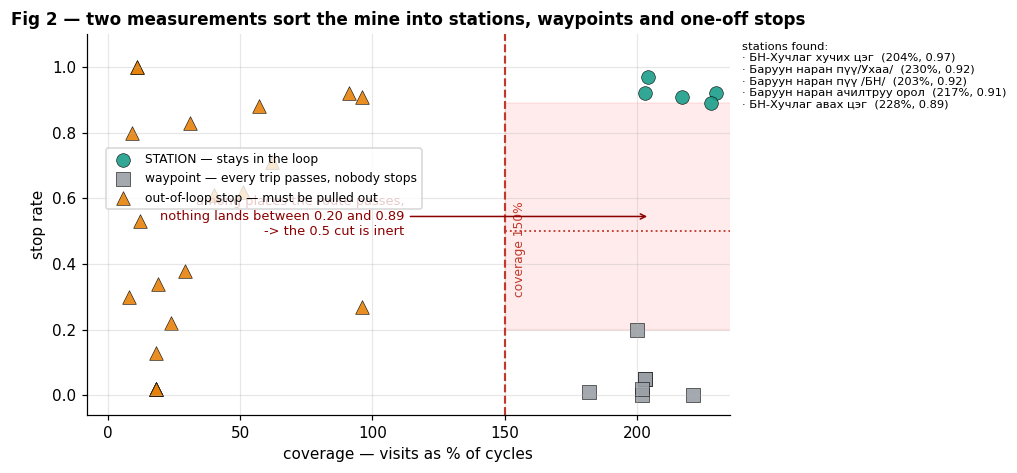

In [5]:
from matplotlib.patches import Rectangle
T = topo[topo.visits >= 200].copy()
onroute = T[T.coverage_pct >= A.STATION_MIN_COV]          # the gap claim holds HERE only —
hi = onroute[onroute.kind == 'station'].stop_rate.min()   # off-loop stops do sit in between,
lo = onroute[onroute.kind == 'waypoint'].stop_rate.max()  # but they are excluded by coverage
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.add_patch(Rectangle((A.STATION_MIN_COV, lo), 240 - A.STATION_MIN_COV, hi - lo,
                       color='red', alpha=.08, zorder=0))
ax.plot([A.STATION_MIN_COV, 240], [A.STATION_MIN_STOPRATE] * 2, ls=':', color=RED, lw=1.2)
ax.axvline(A.STATION_MIN_COV, color=RED, ls='--', lw=1.4)
kinds = {'station': (TEAL, 'o', 'STATION — stays in the loop'),
         'waypoint': (GREY, 's', 'waypoint — every trip passes, nobody stops'),
         'offloop': (ORANGE, '^', 'out-of-loop stop — must be pulled out'),
         'ambiguous': (BLUE, 'x', 'ambiguous')}
for k, (c, mk, lb) in kinds.items():
    s = T[T.kind == k]
    if not len(s): continue
    ax.scatter(s.coverage_pct, s.stop_rate, c=c, marker=mk, s=80, label=lb, alpha=.9,
               edgecolors='k', linewidths=.4)
ax.text(A.STATION_MIN_COV + 3, .30, f'coverage {A.STATION_MIN_COV}%', color=RED, fontsize=8,
        rotation=90, va='bottom')
ax.annotate(f'among places the route passes,\nnothing lands between {lo:.2f} and {hi:.2f}\n'
            f'-> the {A.STATION_MIN_STOPRATE} cut is inert',
            xy=(205, (lo + hi) / 2), xytext=(112, (lo + hi) / 2), fontsize=8.5, color='darkred',
            va='center', ha='right',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1))
# stations sit on top of each other; list them instead of annotating in place
names = [f"{r.label.split('+')[0].strip()[:26]}  ({r.coverage_pct}%, {r.stop_rate:.2f})"
         for _, r in T[T.kind == 'station'].sort_values('stop_rate', ascending=False).iterrows()]
ax.text(1.02, .98, 'stations found:\n' + '\n'.join('· ' + n for n in names),
        transform=ax.transAxes, fontsize=7.5, va='top', family='DejaVu Sans')
ax.set_xlabel('coverage — visits as % of cycles'); ax.set_ylabel('stop rate')
ax.set_ylim(-.06, 1.10); ax.set_xlim(-8, 235)
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(.02, .62))
ax.set_title('Fig 2 — two measurements sort the mine into stations, waypoints and one-off stops',
             fontweight='bold', fontsize=11)
fig.tight_layout(); fig.savefig('nb_v4_fig2_topology.png', dpi=130, bbox_inches='tight')

In [6]:
print('STATIONS (merged complexes, stay in the loop):')
for s in stations:
    print(f"   {s['coverage_pct']:3d}%  stop {s['stop_rate']:.2f}   {s['label']}")
print('\nOUT-OF-LOOP (pulled out; a dispatcher cannot recover a shift handover):')
for o in offloop[:6]:
    print(f"   {o['coverage_pct']:3d}%  stop {o['stop_rate']:.2f}   {o['label']}")
print('\nWAYPOINTS (every trip passes, nobody stops -> their time is DRIVING):')
for _, r in topo[topo.kind == 'waypoint'].head(7).iterrows():
    print(f"   {r.coverage_pct:3d}%  stop {r.stop_rate:.2f}   {r.label}")

STATIONS (merged complexes, stay in the loop):
   230%  stop 0.92   Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг
   217%  stop 0.91   Баруун наран ачилтруу оролт + Баруун наран пүү /БН/ + БН-Хучлаг хучих цэг

OUT-OF-LOOP (pulled out; a dispatcher cannot recover a shift handover):
    96%  stop 0.91   Sp3
    96%  stop 0.27   Баруун наран клонк
    91%  stop 0.92   baruun hard
    62%  stop 0.71   hard 3
    57%  stop 0.88   Режектийн зам
    51%  stop 0.62   buulgalt

WAYPOINTS (every trip passes, nobody stops -> their time is DRIVING):
   221%  stop 0.00   S30 Овоолго
   203%  stop 0.05   эргэлт 1
   203%  stop 0.05   эргэлт2
   202%  stop 0.00   цанхи уулзвар
   202%  stop 0.02   эргэлт3
   200%  stop 0.20   ТЛ замын ачилт
   182%  stop 0.01   SP11


## 3 — Where the minutes actually go

Every GPS interval inside a haul or return leg is charged to exactly one place (smallest
containing box wins), or to *driving* / *stopped-somewhere-unmapped* if it is in no zone. The
identity closes to under 1%, and the classification survives an independent check: during the
intervals we call "stopped", the odometer advances at **0.3 km/h**; during "driving", 35.4 km/h.

In [7]:
boxes = list(stations) + list(offloop)
R = A.decompose_legs(cyc, pings, boxes)
share = (R.drop(columns=['leg','total']).sum()/60).sort_values(ascending=False)
lab = {b['name']: b['label'][:34] for b in boxes}
lab.update(driving='DRIVING', stopped_unmapped='stopped, unmapped')
print(f"leg time {R.total.sum()/60:.0f} truck-h, accounted "
      f"{100*(share.sum()-R.total.sum()/60)/(R.total.sum()/60):+.1f}%\n")
for k, v in share.items():
    print(f"   {lab.get(k,k):36s} {v:6.0f} h   {100*v/share.sum():5.1f}%")

leg time 11220 truck-h, accounted -12.7%

   DRIVING                                4179 h    42.7%
   Баруун наран пүү/Ухаа/ + БН-Хучлаг     1265 h    12.9%
   Баруун наран ачилтруу оролт + Бару     1093 h    11.2%
   Засварын паркын талбай                  789 h     8.1%
   stopped, unmapped                       770 h     7.9%
   БН шинэ паркын талбай                   691 h     7.1%
   Sp3                                     534 h     5.4%
   2-р км                                  247 h     2.5%
   Баруун наран клонк                      142 h     1.4%
   baruun hard                              25 h     0.3%
   Terminal Middling овоолго                17 h     0.2%
   ПАРКЫН ТАЛБАЙ                            16 h     0.2%
   Режектийн зам                             8 h     0.1%
   мидлинг буулгалт                          4 h     0.0%
   ER клонк                                  3 h     0.0%
   Hard sp5                                  3 h     0.0%
   staker shine               

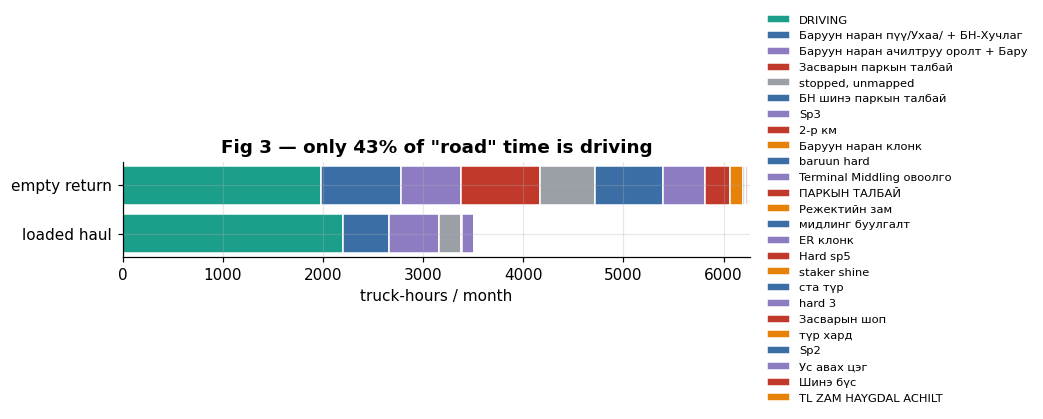

In [8]:
order = list(share.index)
fig, ax = plt.subplots(figsize=(9.6, 2.7))
cols = [TEAL if o == 'driving' else GREY if o == 'stopped_unmapped'
        else [ORANGE, BLUE, '#8e7cc3', RED][i % 4] for i, o in enumerate(order)]
for legname, y in [('haul', 'loaded haul'), ('ret', 'empty return')]:
    left = 0
    for i, o in enumerate(order):
        v = R[R.leg == legname][o].sum()/60
        ax.barh(y, v, left=left, color=cols[i], edgecolor='w',
                label=lab.get(o, o) if legname == 'haul' else None)
        left += v
dp = 100*R['driving'].sum()/R.drop(columns=['leg','total']).sum().sum()
ax.set_xlabel('truck-hours / month')
ax.legend(fontsize=7.5, ncol=1, loc='center left', bbox_to_anchor=(1.01, .5), frameon=False)
ax.set_title(f'Fig 3 — only {dp:.0f}% of "road" time is driving', fontweight='bold')
fig.tight_layout(); fig.savefig('nb_v4_fig3_legs.png', dpi=130, bbox_inches='tight')

### Splitting a station's time without inventing another percentile

For each visit we count how many other trucks were already inside on arrival.

* **service** = min(dwell, *median dwell when nobody else was there*) — measured, not chosen
* **queue** = the excess when ≥1 truck was already there
* **solo-long** = the excess with nobody there. We refuse to put this in either bucket; its
  cause is unknown (a breakdown, a break, a tarp that went wrong) and pretending otherwise
  would either inflate the service time or invent a queue.

The check that licenses reading the middle one as a queue is that dwell must rise with
concurrency. It does — though more weakly than at the shovel (Spearman ≈0.2 vs 0.35), so it is
evidence, not proof.

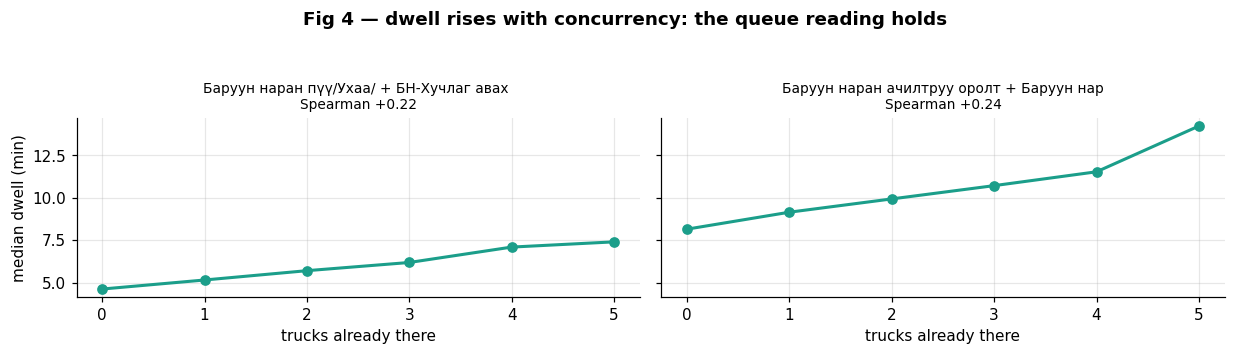

In [9]:
fig, axes = plt.subplots(1, len(stations), figsize=(5.6*len(stations), 3.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, b in zip(axes, stations):
    V = A._visits(pings, b)
    g = V.groupby(V.conc.clip(upper=5))['min'].median()
    ax.plot(g.index, g.values, 'o-', color=TEAL, lw=2)
    r = V[['conc','min']].corr(method='spearman').iloc[0,1]
    ax.set_title(f"{b['label'][:40]}\nSpearman {r:+.2f}", fontsize=9)
    ax.set_xlabel('trucks already there')
axes[0].set_ylabel('median dwell (min)')
fig.suptitle('Fig 4 — dwell rises with concurrency: the queue reading holds', fontweight='bold', y=1.06)
fig.tight_layout(); fig.savefig('nb_v4_fig4_conc.png', dpi=130, bbox_inches='tight')

## 4 — The diagnosis, and what changed

In [10]:
dx = A.diagnose_v2(ZONE, MONTH, with_band=False)
print(A.report(dx))

DIAGNOSIS v2 — BN load (Баруун наран /Зүүн/) (zone 25559, 2025-11)
THROUGHPUT : 88.6 loads/day | 22 trucks | 21h active/day
METHOD     : ping layer: six stations, causal service times
STATIONS   : shovel 7.6/h busy 56% | dump 8.9/h busy 48%  -> binding = SHOVEL  (not saturated)
             loop 282.4 min | cycling 417 truck-h/day
ROAD LEGS  : only 43% of 'road' time is actually driving (accounting closes to 0.0%)

ROADSIDE STATIONS (every trip passes these, both ways):
   station                         total service  queue solo-long  svc min  conc r
   Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг   1265     402    769        94      4.6    0.22
   Баруун наран ачилтруу оролт + Баруун наран пүү /БН/ + БН-Хучлаг хучих цэг   1093     592    470        31      8.2    0.24

IN-LOOP WASTE (truck-h/mo, by CAUSE):
   stopped_unmapped            770 h
   z27840_27839_queue          769 h
   queue_shovel                493 h
   z27928_25560_25561_queue    470 h
   road_return                 33

The comparison below is the cycle-table-only path against the ping layer, and it is the single
most important check in this notebook. Without ping-level positions a leg is just two timestamps
subtracted, and the empty-return road looks like the dominant problem. It is not: most of that
time is a truck standing still somewhere along the route.


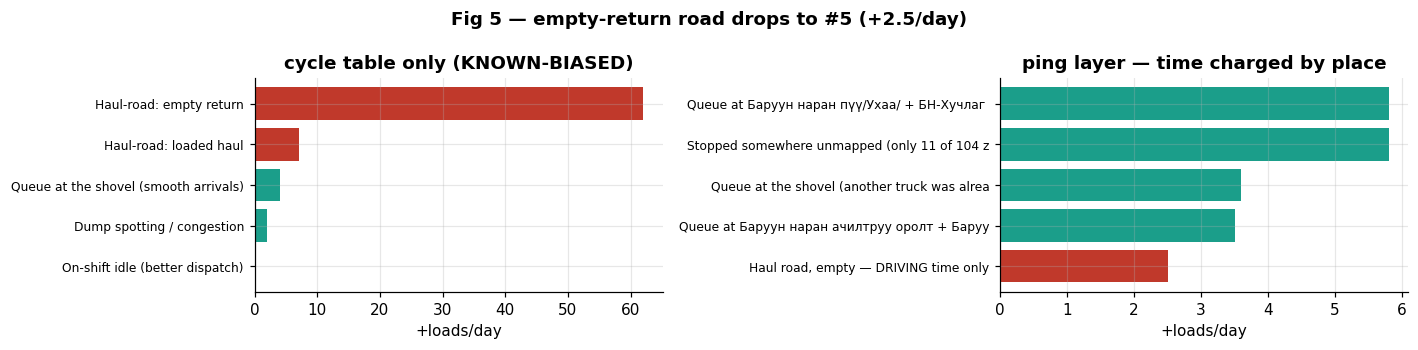

In [11]:
old = A.diagnose_v2(ZONE, MONTH, with_band=False, use_pings=False)
pairs = [([(l['cause'][:44], l['gain']) for l in old['levers'][:5]], 'cycle table only (KNOWN-BIASED)'),
         ([(l['cause'][:44], l['gain']) for l in dx['levers'][:5]], 'ping layer — time charged by place')]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
for a_, (dat, t) in zip(ax, pairs):
    labs = [x[0] for x in dat][::-1]; val = [x[1] for x in dat][::-1]
    cols = [RED if 'road' in l.lower() else TEAL for l in labs]
    a_.barh(range(len(labs)), val, color=cols)
    a_.set_yticks(range(len(labs))); a_.set_yticklabels(labs, fontsize=8)
    a_.set_title(t, fontweight='bold'); a_.set_xlabel('+loads/day')
rr = [l for l in dx['levers'] if l['key'] == 'road_return']
sub = f"empty-return road drops to #{rr[0]['rank']} (+{rr[0]['gain']:.1f}/day)" if rr else ''
fig.suptitle(f'Fig 5 — {sub}', fontweight='bold')
fig.tight_layout(); fig.savefig('nb_v4_fig5_flip.png', dpi=130)


## 5 — A recommendation per month

Same code, five months, nothing tuned in between. The agent also says whether its #1 is a real
winner or a tie: ranks only ever swap when #1 and #2 sit within a few loads/day of each other,
so below that margin it refuses to name a single winner.

In [12]:
rows = []
for m in MONTHS:
    d = A.diagnose_v2(ZONE, m, with_band=False)
    rr = [l for l in d['levers'] if l['key'] == 'road_return'][0]
    qs = [l for l in d['levers'] if l['key'] == 'queue_shovel'][0]
    rows.append(dict(month=m, loads_day=d['throughput']['loads_day'],
                     rho_shovel=d['stations']['rho_shovel'], saturated=d['stations']['saturated'],
                     stations_found=len(d['roadside_stations']),
                     driving_pct=d['leg_decomposition']['driving_share_pct'],
                     top_lever=d['levers'][0]['cause'][:34], margin=d['lever_verdict']['margin'],
                     tied=d['lever_verdict']['tied'],
                     shovel_queue_rank=qs['rank'], road_return_rank=rr['rank'],
                     floor_pct=d['headline']['lower_bound_pct'],
                     ceil_pct=d['headline']['upper_bound_pct']))
M = pd.DataFrame(rows); M.to_csv('v4_five_months.csv', index=False)
M

,month,loads_day,rho_shovel,saturated,stations_found,driving_pct,top_lever,margin,tied,shovel_queue_rank,road_return_rank,floor_pct,ceil_pct
0,2025-07,52.4,0.42,False,2,38,Queue at Баруун наран пүү/Ухаа/ +,2.4,True,7,3,31,36
1,2025-08,87.4,0.55,False,2,35,Queue at Баруун наран пүү/Ухаа/ +,4.6,True,6,4,22,44
2,2025-09,84.5,0.54,False,2,39,Queue at Баруун наран пүү/Ухаа/ +,0.5,True,5,4,36,40
3,2025-10,98.9,0.63,False,2,38,Stopped somewhere unmapped (only 1,1.1,True,3,5,30,36
4,2025-11,88.6,0.56,False,2,43,Queue at Баруун наран пүү/Ухаа/ +,0.0,True,3,5,21,38


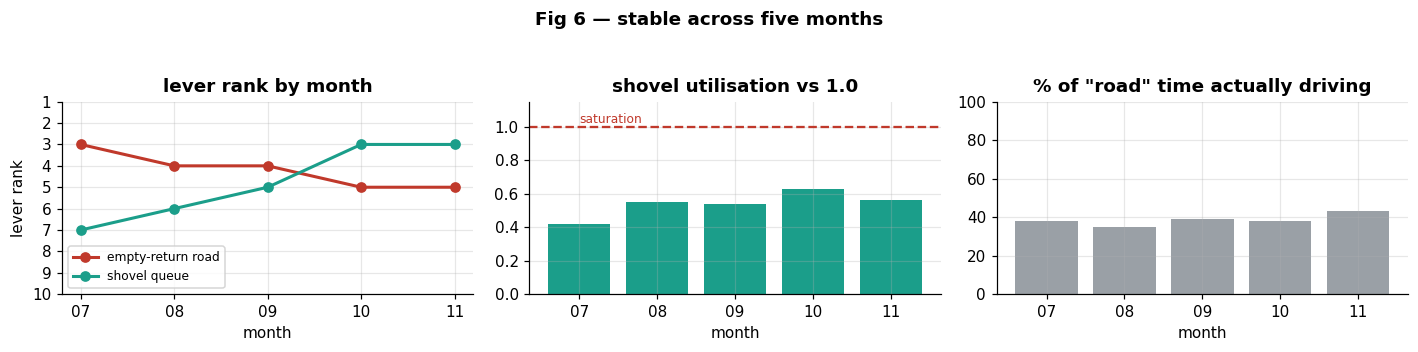

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.0))
x = range(len(M))
ax[0].plot(x, M.road_return_rank, 'o-', color=RED, lw=2, label='empty-return road')
ax[0].plot(x, M.shovel_queue_rank, 'o-', color=TEAL, lw=2, label='shovel queue')
ax[0].invert_yaxis(); ax[0].set_yticks(range(1, 11)); ax[0].set_ylabel('lever rank')
ax[0].legend(fontsize=8); ax[0].set_title('lever rank by month', fontweight='bold')
ax[1].bar(x, M.rho_shovel, color=TEAL); ax[1].axhline(1.0, color=RED, ls='--')
ax[1].text(0, 1.02, 'saturation', color=RED, fontsize=8); ax[1].set_ylim(0, 1.15)
ax[1].set_title('shovel utilisation vs 1.0', fontweight='bold')
ax[2].bar(x, M.driving_pct, color=GREY); ax[2].set_ylim(0, 100)
ax[2].set_title('% of "road" time actually driving', fontweight='bold')
for a_ in ax:
    a_.set_xticks(list(x)); a_.set_xticklabels([m[-2:] for m in M.month]); a_.set_xlabel('month')
fig.suptitle('Fig 6 — stable across five months', fontweight='bold', y=1.05)
fig.tight_layout(); fig.savefig('nb_v4_fig6_months.png', dpi=130, bbox_inches='tight')

### The headline is a range

The old single figure compared a *contaminated* "now" — the monthly mean quietly includes real
stoppage days — against a ceiling never once approached in 150 days. Both ends were wrong in the
same direction.

* **Floor**: every normal day matches this fleet's *own best day*. No baseline quantile, no
  service rate, no extrapolation — it happened. It is a lower bound, and weak in one specific
  way: it measures day-to-day *inconsistency*, so a uniformly slow mine would score +0% and
  still have plenty to gain.
* **Ceiling**: all in-loop waste removed at once. Never observed, and it leans on a capacity
  figure that moves 125–273 loads/day under plausible parameters.

We report both and claim neither as the answer.

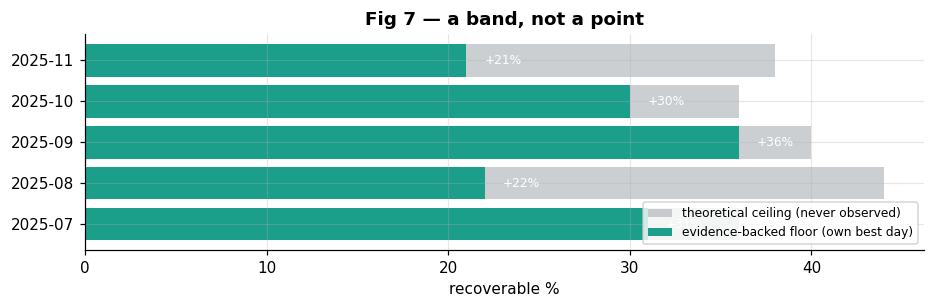

In [14]:
fig, ax = plt.subplots(figsize=(8.6, 2.9))
y = range(len(M))
ax.barh(y, M.ceil_pct, color=GREY, alpha=.5, label='theoretical ceiling (never observed)')
ax.barh(y, M.floor_pct, color=TEAL, label='evidence-backed floor (own best day)')
for i, r in M.iterrows():
    ax.text(r.floor_pct+1, i, f"+{r.floor_pct}%", va='center', fontsize=8,
            color='white' if r.floor_pct > 12 else 'black')
ax.set_yticks(list(y)); ax.set_yticklabels(M.month); ax.set_xlabel('recoverable %')
ax.legend(fontsize=8, loc='lower right')
ax.set_title('Fig 7 — a band, not a point', fontweight='bold')
fig.tight_layout(); fig.savefig('nb_v4_fig7_range.png', dpi=130)

In [15]:
o = dx['observed']
print(f"BN {MONTH}: {o['normal_days']} normal days, {o['stoppage_days']} stoppage days")
print(f"  now {o['current_loads_day']}/day -> own best day {o['best_day']} = +{o['gain_pct_best']}%")
print(f"  split: more trucks out +{o['from_more_trucks_pct']}% (maintenance) | "
      f"trips per truck +{o['from_trips_per_truck_pct']}% (dispatch)")
print(f"  stoppage days cost {o['stoppage_lost_loads']} loads = "
      f"{o['stoppage_lost_share_pct']}% of the month")

BN 2025-11: 26 normal days, 4 stoppage days
  now 98.8/day -> own best day 120 = +21%
  split: more trucks out +6% (maintenance) | trips per truck +13% (dispatch)
  stoppage days cost 308 loads = 12% of the month


## 6 — Reusability: hand it a month it has never seen

The claim only means something if it is tested. Below we delete November from the pre-baked
cycle table, so the agent has to rebuild the cycles from raw GPS, rediscover the topology, and
re-derive the recommendation with no human in the loop. A December file would take exactly this
path.

In [16]:
import copy, time
saved = A._CYCLES
A._CYCLES = A._cycles_df().copy()
A._CYCLES = A._CYCLES[A._CYCLES.month != MONTH]
print('cycle table now holds:', sorted(A._CYCLES.month.unique()), '\n')
t0 = time.time()
fresh = A.diagnose_v2(ZONE, MONTH, with_band=False)
print(f"rebuilt from raw GPS in {time.time()-t0:.0f}s")
print(f"  cycles           {fresh['throughput']}")
print(f"  stations found   {[s['label'][:44] for s in fresh['roadside_stations'].values()]}")
print(f"  #1 lever         {fresh['levers'][0]['cause']}  +{fresh['levers'][0]['gain']}/day")
print(f"  verdict          {fresh['lever_verdict']['note']}")
print(f"  headline         +{fresh['headline']['lower_bound_pct']}% .. "
      f"+{fresh['headline']['upper_bound_pct']}%")
A._CYCLES = saved

cycle table now holds: ['2025-07', '2025-08', '2025-09', '2025-10'] 



rebuilt from raw GPS in 5s
  cycles           {'loads_day': 88.6, 'trucks': 22, 'days': 30, 'op_hours': 21}
  stations found   ['Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг', 'Баруун наран ачилтруу оролт + Баруун наран п']
  #1 lever         Queue at Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг  +5.8/day
  verdict          #1 and #2 are within the parameter wobble — report them as tied
  headline         +21% .. +38%


## What holds, and what we are not claiming

**The shovel is not the constraint.** Utilisation stays between 0.42 and 0.63 across all five
months, and of every station in the loop the shovel is still the one closest to saturating. A
queue in front of a server that is idle half the time is the signature of bunched arrivals, not
of missing capacity — buying shovel capacity would not help. This is also the point where the
method agrees with the collaborator's own utilisation table.

**The queue at the load zone is the best-evidenced finding.** The stay rises monotonically with
the number of trucks already there — 13 minutes with nobody, 40 with five or more, Spearman 0.69
over 2 655 trips. That is about as clean a dose-response as observational data gives.

**There is no first priority.** Two items are level at the top and two more are close behind; no
lever clears the 5 loads/day margin in any of the five months. The output is a group of
comparable items, not a ranked list, and the rule that says so is deliberate.

**The largest identified item is a gap in the data, not a finding.** 770 truck-hours of trucks
standing still in places that have no polygon — 93 of the 104 zones have only a bounding box.
Obtaining the remaining outlines would do more than anything currently rankable.

**Units and status.** No payload data, so loads and truck-hours, never tonnes. One material flow,
one mine, July to November, no winter. And this is a diagnosis: proving that acting on any of
these produces the gain requires a before/after pilot.
